# Analisis Explotario de Datos (Pharma sales)

## 1. Importar librerias

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbn

## 2. Cargas los CSV principales

In [5]:
df_hourly = pd.read_csv('../data/pharma_sales/saleshourly.csv')
df_daily = pd.read_csv('../data/pharma_sales/salesdaily.csv')
df_weekly = pd.read_csv('../data/pharma_sales/salesweekly.csv')
df_monthly = pd.read_csv('../data/pharma_sales/salesmonthly.csv')

## 3. Dimensiones de las tablas cargadas

In [6]:
print("Hourly:", df_hourly.shape)
print("Daily:", df_daily.shape)
print("Weekly:", df_weekly.shape)
print("Monthly:", df_monthly.shape)

Hourly: (50532, 13)
Daily: (2106, 13)
Weekly: (302, 9)
Monthly: (70, 9)


## 4. Vista inicial de las talbas principales

In [28]:
display(df_hourly.head())
df_hourly.info()
display(df_hourly.describe())

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,2014-01-02 08:00:00,0.0,0.67,0.4,2.0,0.0,0.0,0.0,1.0,2014,1,8,Thursday
1,2014-01-02 09:00:00,0.0,0.00,1.0,0.0,2.0,0.0,0.0,0.0,2014,1,9,Thursday
2,2014-01-02 10:00:00,0.0,0.00,0.0,3.0,2.0,0.0,0.0,0.0,2014,1,10,Thursday
3,2014-01-02 11:00:00,0.0,0.00,0.0,2.0,1.0,0.0,0.0,0.0,2014,1,11,Thursday
4,2014-01-02 12:00:00,0.0,2.00,0.0,5.0,2.0,0.0,0.0,0.0,2014,1,12,Thursday


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50532 entries, 0 to 50531
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   datum         50532 non-null  datetime64[ns]
 1   M01AB         50532 non-null  float64       
 2   M01AE         50532 non-null  float64       
 3   N02BA         50532 non-null  float64       
 4   N02BE         50532 non-null  float64       
 5   N05B          50532 non-null  float64       
 6   N05C          50532 non-null  float64       
 7   R03           50532 non-null  float64       
 8   R06           50532 non-null  float64       
 9   Year          50532 non-null  int64         
 10  Month         50532 non-null  int64         
 11  Hour          50532 non-null  int64         
 12  Weekday Name  50532 non-null  object        
dtypes: datetime64[ns](1), float64(8), int64(3), object(1)
memory usage: 5.0+ MB


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour
count,50532,50532.000000,50532.000000,50532.000000,50532.000000,50532.000000,50532.000000,50532.000000,50532.000000,50532.000000,50532.000000,50532.000000
mean,2016-11-20 01:30:00,0.209787,0.162365,0.161723,1.246842,0.368989,0.024736,0.229732,0.120870,2016.401409,6.344811,11.500475
min,2014-01-02 08:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2014.000000,1.000000,0.000000
25%,2015-06-12 16:45:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2015.000000,3.000000,6.000000
50%,2016-11-20 01:30:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2016.000000,6.000000,12.000000
75%,2018-04-30 10:15:00,0.000000,0.000000,0.000000,1.875000,0.000000,0.000000,0.000000,0.000000,2018.000000,9.000000,17.000000
max,2019-10-08 19:00:00,7.000000,6.000000,6.500000,29.000000,15.000000,6.000000,25.000000,5.000000,2019.000000,12.000000,23.000000
std,NaN,0.556003,0.416109,0.453211,2.387392,0.930934,0.217871,1.240513,0.391999,1.664444,3.385761,6.921706


In [27]:
display(df_daily.head())
df_daily.info()
display(df_daily.describe())

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,2014-01-02,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,2014-01-03,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,2014-01-04,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,2014-01-05,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,2014-01-06,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   datum         2106 non-null   datetime64[ns]
 1   M01AB         2106 non-null   float64       
 2   M01AE         2106 non-null   float64       
 3   N02BA         2106 non-null   float64       
 4   N02BE         2106 non-null   float64       
 5   N05B          2106 non-null   float64       
 6   N05C          2106 non-null   float64       
 7   R03           2106 non-null   float64       
 8   R06           2106 non-null   float64       
 9   Year          2106 non-null   int64         
 10  Month         2106 non-null   int64         
 11  Hour          2106 non-null   int64         
 12  Weekday Name  2106 non-null   object        
dtypes: datetime64[ns](1), float64(8), int64(3), object(1)
memory usage: 214.0+ KB


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour
count,2106,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000
mean,2016-11-19 12:00:00.000000256,5.033683,3.895830,3.880441,29.917095,8.853627,0.593522,5.512262,2.900198,2016.401235,6.344255,275.945869
min,2014-01-02 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2014.000000,1.000000,190.000000
25%,2015-06-12 06:00:00,3.000000,2.340000,2.000000,19.000000,5.000000,0.000000,1.000000,1.000000,2015.000000,3.000000,276.000000
50%,2016-11-19 12:00:00,4.990000,3.670000,3.500000,26.900000,8.000000,0.000000,4.000000,2.000000,2016.000000,6.000000,276.000000
75%,2018-04-29 18:00:00,6.670000,5.138000,5.200000,38.300000,12.000000,1.000000,8.000000,4.000000,2018.000000,9.000000,276.000000
max,2019-10-08 00:00:00,17.340000,14.463000,16.000000,161.000000,54.833333,9.000000,45.000000,15.000000,2019.000000,12.000000,276.000000
std,NaN,2.737579,2.133337,2.384010,15.590966,5.605605,1.092988,6.428736,2.415816,1.665060,3.386954,1.970547


In [26]:
display(df_weekly.head())
df_weekly.info()
display(df_weekly.describe())

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
0,2014-01-05,14.00,11.67,21.3,185.95,41.0,0.0,32.0,7.0
1,2014-01-12,29.33,12.68,37.9,190.70,88.0,5.0,21.0,7.2
2,2014-01-19,30.67,26.34,45.9,218.40,80.0,8.0,29.0,12.0
3,2014-01-26,34.00,32.37,31.5,179.60,80.0,8.0,23.0,10.0
4,2014-02-02,31.02,23.35,20.7,159.88,84.0,12.0,29.0,12.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   datum   302 non-null    datetime64[ns]
 1   M01AB   302 non-null    float64       
 2   M01AE   302 non-null    float64       
 3   N02BA   302 non-null    float64       
 4   N02BE   302 non-null    float64       
 5   N05B    302 non-null    float64       
 6   N05C    302 non-null    float64       
 7   R03     302 non-null    float64       
 8   R06     302 non-null    float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 21.4 KB


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
count,302,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,2016-11-23 12:00:00,35.102441,27.167611,27.060295,208.627161,61.740853,4.138935,38.439811,20.224561
min,2014-01-05 00:00:00,7.670000,6.237000,3.500000,86.250000,18.000000,0.000000,2.000000,1.000000
25%,2015-06-15 18:00:00,29.387500,22.387500,21.300000,149.300000,47.000000,2.000000,21.000000,11.475000
50%,2016-11-23 12:00:00,34.565000,26.789500,26.500000,198.300000,57.000000,3.979167,35.000000,17.500000
75%,2018-05-04 06:00:00,40.175000,31.046500,32.475000,252.471500,71.000000,6.000000,51.000000,26.000000
max,2019-10-13 00:00:00,65.330000,53.571000,60.125000,546.899000,154.000000,17.000000,131.000000,65.000000
std,NaN,8.617106,7.043491,8.086458,76.069221,22.436970,3.129265,22.900873,11.381464


In [25]:
display(df_monthly.head())
df_monthly.info()
display(df_monthly.describe())

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
0,2014-01-31,127.69,99.090,152.100,878.030,354.0,50.0,112.0,48.2
1,2014-02-28,133.32,126.050,177.000,1001.900,347.0,31.0,122.0,36.2
2,2014-03-31,137.44,92.950,147.655,779.275,232.0,20.0,112.0,85.4
3,2014-04-30,113.10,89.475,130.900,698.500,209.0,18.0,97.0,73.7
4,2014-05-31,101.79,119.933,132.100,628.780,270.0,23.0,107.0,123.7


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   datum   70 non-null     datetime64[ns]
 1   M01AB   70 non-null     float64       
 2   M01AE   70 non-null     float64       
 3   N02BA   70 non-null     float64       
 4   N02BE   70 non-null     float64       
 5   N05B    70 non-null     float64       
 6   N05C    70 non-null     float64       
 7   R03     70 non-null     float64       
 8   R06     70 non-null     float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 5.1 KB


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
count,70,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000
mean,2016-12-14 15:05:08.571428608,149.992000,116.514286,115.020843,892.542071,262.118571,17.842857,167.675000,86.662571
min,2014-01-31 00:00:00,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,2015-07-07 18:00:00,137.490000,103.518250,94.375000,648.187500,223.750000,12.000000,112.000000,49.875000
50%,2016-12-15 12:00:00,154.635000,114.840000,117.225000,865.824500,250.300000,18.000000,160.000000,74.100000
75%,2018-05-23 06:00:00,169.000000,128.359750,133.837500,1061.580000,293.650000,23.000000,218.250000,119.807500
max,2019-10-31 00:00:00,211.130000,222.351000,191.600000,1856.815000,492.000000,50.000000,386.000000,213.040000
std,NaN,31.485325,27.889336,31.245899,338.843908,85.060930,8.481242,81.767979,45.859336


## 5. Calidad inicial de datos


### 5.1 Revisar valores faltantes por tabla

In [11]:
def missing_summary(df, table_name):
    missing = pd.DataFrame({
        "columna": df.columns,
        "valores_faltantes": df.isnull().sum().values,
        "porcentaje_faltante": (df.isnull().sum().values / len(df)) * 100
    })

    missing = missing.sort_values("porcentaje_faltante", ascending=False)

    print(f"\nValores faltantes en {table_name}")
    return missing

In [12]:
missing_summary(df_hourly, "df_hourly")


Valores faltantes en df_hourly


,columna,valores_faltantes,porcentaje_faltante
0,datum,0,0.0
1,M01AB,0,0.0
2,M01AE,0,0.0
3,N02BA,0,0.0
4,N02BE,0,0.0
5,N05B,0,0.0
6,N05C,0,0.0
7,R03,0,0.0
8,R06,0,0.0
9,Year,0,0.0


In [13]:
missing_summary(df_daily, "df_daily")


Valores faltantes en df_daily


,columna,valores_faltantes,porcentaje_faltante
0,datum,0,0.0
1,M01AB,0,0.0
2,M01AE,0,0.0
3,N02BA,0,0.0
4,N02BE,0,0.0
5,N05B,0,0.0
6,N05C,0,0.0
7,R03,0,0.0
8,R06,0,0.0
9,Year,0,0.0


In [14]:
missing_summary(df_weekly, "df_weekly")


Valores faltantes en df_weekly


,columna,valores_faltantes,porcentaje_faltante
0,datum,0,0.0
1,M01AB,0,0.0
2,M01AE,0,0.0
3,N02BA,0,0.0
4,N02BE,0,0.0
5,N05B,0,0.0
6,N05C,0,0.0
7,R03,0,0.0
8,R06,0,0.0


In [15]:
missing_summary(df_monthly, "df_monthly")


Valores faltantes en df_monthly


,columna,valores_faltantes,porcentaje_faltante
0,datum,0,0.0
1,M01AB,0,0.0
2,M01AE,0,0.0
3,N02BA,0,0.0
4,N02BE,0,0.0
5,N05B,0,0.0
6,N05C,0,0.0
7,R03,0,0.0
8,R06,0,0.0


### 5.2 Revisar duplicados

In [16]:
print("Duplicados en df_hourly:", df_hourly.duplicated().sum())
print("Duplicados en df_daily:", df_daily.duplicated().sum())
print("Duplicados en df_weekly:", df_weekly.duplicated().sum())
print("Duplicados en df_monthly:", df_monthly.duplicated().sum())

Duplicados en df_hourly: 0
Duplicados en df_daily: 0
Duplicados en df_weekly: 0
Duplicados en df_monthly: 0


## 6. Conversión de fechas

In [17]:
df_hourly['datum'] = pd.to_datetime(df_hourly['datum'])
df_daily['datum'] = pd.to_datetime(df_daily['datum'])
df_weekly['datum'] = pd.to_datetime(df_weekly['datum'])
df_monthly['datum'] = pd.to_datetime(df_monthly['datum'])

print("Tipo de dato en Hourly:", df_hourly['datum'].dtype)
print("Ejemplo de fecha convertida:", df_hourly['datum'].iloc[0])

Tipo de dato en Hourly: datetime64[ns]
Ejemplo de fecha convertida: 2014-01-02 08:00:00


In [18]:
for df in [df_hourly, df_daily, df_weekly, df_monthly]:
    df.set_index('datum', inplace=True)
    df.sort_index(inplace=True)
    df.reset_index(inplace=True)

df_hourly.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,2014-01-02 08:00:00,0.0,0.67,0.4,2.0,0.0,0.0,0.0,1.0,2014,1,8,Thursday
1,2014-01-02 09:00:00,0.0,0.00,1.0,0.0,2.0,0.0,0.0,0.0,2014,1,9,Thursday
2,2014-01-02 10:00:00,0.0,0.00,0.0,3.0,2.0,0.0,0.0,0.0,2014,1,10,Thursday
3,2014-01-02 11:00:00,0.0,0.00,0.0,2.0,1.0,0.0,0.0,0.0,2014,1,11,Thursday
4,2014-01-02 12:00:00,0.0,2.00,0.0,5.0,2.0,0.0,0.0,0.0,2014,1,12,Thursday


### 6.1 Verificar conversión

In [19]:
df_hourly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50532 entries, 0 to 50531
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   datum         50532 non-null  datetime64[ns]
 1   M01AB         50532 non-null  float64       
 2   M01AE         50532 non-null  float64       
 3   N02BA         50532 non-null  float64       
 4   N02BE         50532 non-null  float64       
 5   N05B          50532 non-null  float64       
 6   N05C          50532 non-null  float64       
 7   R03           50532 non-null  float64       
 8   R06           50532 non-null  float64       
 9   Year          50532 non-null  int64         
 10  Month         50532 non-null  int64         
 11  Hour          50532 non-null  int64         
 12  Weekday Name  50532 non-null  object        
dtypes: datetime64[ns](1), float64(8), int64(3), object(1)
memory usage: 5.0+ MB


In [20]:
df_daily.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   datum         2106 non-null   datetime64[ns]
 1   M01AB         2106 non-null   float64       
 2   M01AE         2106 non-null   float64       
 3   N02BA         2106 non-null   float64       
 4   N02BE         2106 non-null   float64       
 5   N05B          2106 non-null   float64       
 6   N05C          2106 non-null   float64       
 7   R03           2106 non-null   float64       
 8   R06           2106 non-null   float64       
 9   Year          2106 non-null   int64         
 10  Month         2106 non-null   int64         
 11  Hour          2106 non-null   int64         
 12  Weekday Name  2106 non-null   object        
dtypes: datetime64[ns](1), float64(8), int64(3), object(1)
memory usage: 214.0+ KB


In [21]:
df_weekly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   datum   302 non-null    datetime64[ns]
 1   M01AB   302 non-null    float64       
 2   M01AE   302 non-null    float64       
 3   N02BA   302 non-null    float64       
 4   N02BE   302 non-null    float64       
 5   N05B    302 non-null    float64       
 6   N05C    302 non-null    float64       
 7   R03     302 non-null    float64       
 8   R06     302 non-null    float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 21.4 KB


In [22]:
df_monthly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   datum   70 non-null     datetime64[ns]
 1   M01AB   70 non-null     float64       
 2   M01AE   70 non-null     float64       
 3   N02BA   70 non-null     float64       
 4   N02BE   70 non-null     float64       
 5   N05B    70 non-null     float64       
 6   N05C    70 non-null     float64       
 7   R03     70 non-null     float64       
 8   R06     70 non-null     float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 5.1 KB


# 7. Análisis

## 7.1 Distribución de promedios de venta diaria según el ciclo semanal (Lunes-Domingo)

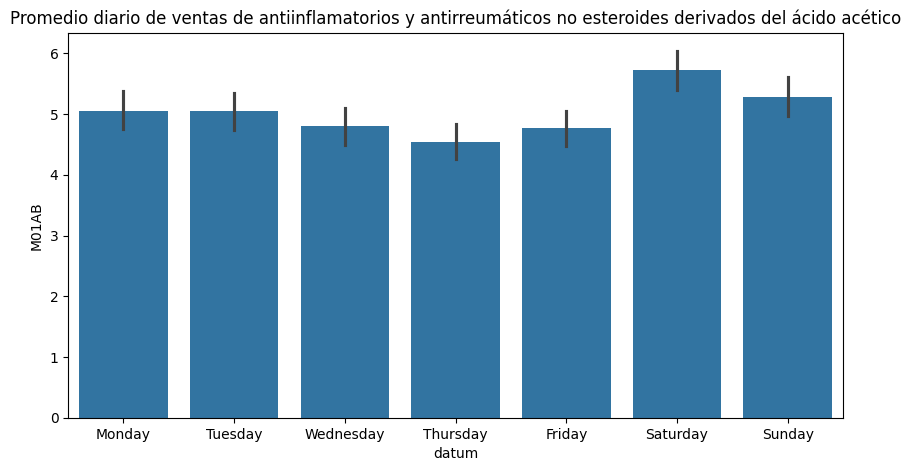

In [23]:
plt.figure(figsize=(10,5))
sbn.barplot(x=df_daily['datum'].dt.day_name(), y='M01AB', data=df_daily, order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('Promedio diario de ventas de antiinflamatorios y antirreumáticos no esteroides derivados del ácido acético')
plt.show()

## 7.2 Matriz de correlación de Pearson

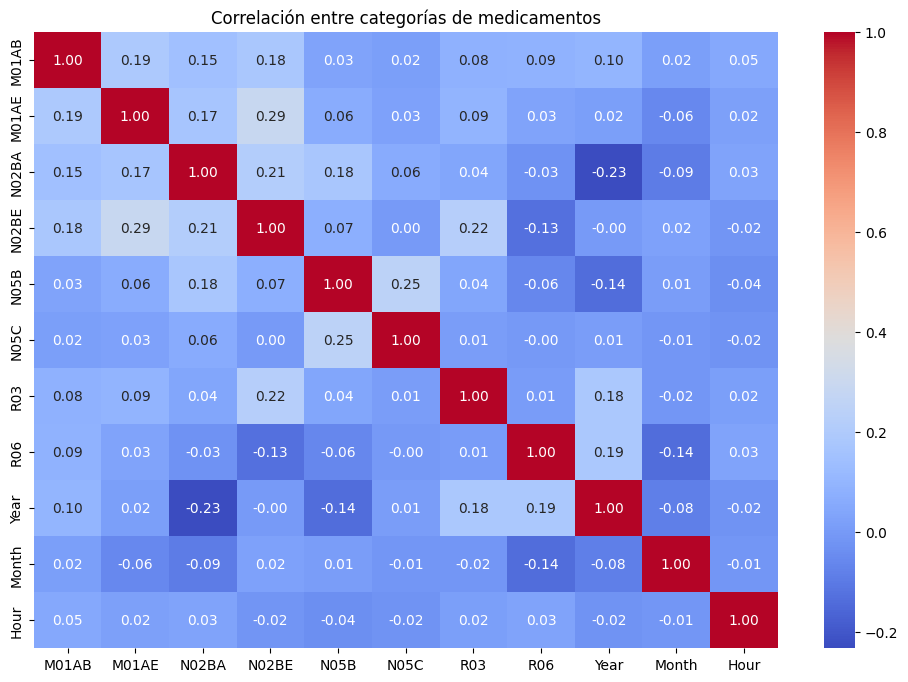

In [24]:
plt.figure(figsize=(12, 8))


df_numeric = df_daily.select_dtypes(include=[np.number])

corr = df_numeric.corr()
sbn.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlación entre categorías de medicamentos')
plt.show()